# Hard determinism

In [1]:
# Hard determinism: ensure reproducible results across runs
import os
import random
import numpy as np

SEED = 0

# Stable hashing
os.environ["PYTHONHASHSEED"] = str(SEED)

# Python + numpy seeds
random.seed(SEED)
np.random.seed(SEED)

# Torch seed
import torch
torch.manual_seed(SEED)

# Deterministic operations
torch.use_deterministic_algorithms(True)

print("SEED:", SEED)

/Users/rawanr/opt/anaconda3/lib/python3.9/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


SEED: 0


# Imports + Paths

In [2]:
from pathlib import Path
import time, shutil
import yaml
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from ultralytics import YOLO

PROJECT_DIR = Path(os.getenv("PROJECT_DIR", Path.cwd())).resolve()
DATA_DIR = PROJECT_DIR / "data"
RUNS_DIR = PROJECT_DIR / "runs"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"

for d in [DATA_DIR, RUNS_DIR, ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)

# COCO80 ids: person=0, car=2, truck=7, traffic light=9
COCO_ID_MAP = {0: 0, 2: 1, 7: 2, 9: 3}
CLASS_NAMES = ["person", "car", "truck", "traffic light"]
NC = len(CLASS_NAMES)

PROJECT_DIR: /Users/rawanr/Downloads/AI_Assessment_Submission



# Helpers (IO, labels, stats, metrics)

In [3]:
def list_images(folder: Path):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

def read_yolo_label_file(p: Path):
    if not p.exists():
        return []
    lines = [ln.strip() for ln in p.read_text(encoding="utf-8").splitlines() if ln.strip()]
    out = []
    for ln in lines:
        parts = ln.split()
        if len(parts) >= 5:
            out.append(parts)
    return out

def write_yolo_label_file(p: Path, rows):
    p.parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        p.write_text("", encoding="utf-8")
        return
    txt = "\n".join(" ".join(map(str, r)) for r in rows) + "\n"
    p.write_text(txt, encoding="utf-8")

def dataset_split_stats(dataset_root: Path, class_names):
    stats = {}
    for split in ["train", "val", "test"]:
        img_dir = dataset_root / "images" / split
        lbl_dir = dataset_root / "labels" / split
        imgs = list_images(img_dir)

        class_counts = {c: 0 for c in class_names}
        instances = 0
        missing = 0

        for img_path in imgs:
            lp = lbl_dir / f"{img_path.stem}.txt"
            if not lp.exists():
                missing += 1
                continue
            rows = read_yolo_label_file(lp)
            for r in rows:
                cid = int(float(r[0]))
                if 0 <= cid < len(class_names):
                    class_counts[class_names[cid]] += 1
                instances += 1

        stats[split] = {
            "images": len(imgs),
            "instances": instances,
            "missing_label_files": missing,
            "class_counts": class_counts
        }
    return stats

def eval_model(model_path: str, data_yaml: str, split="test", imgsz=640, conf=0.01, iou=0.7):
    m = YOLO(model_path)
    r = m.val(
        data=data_yaml,
        split=split,
        imgsz=imgsz,
        conf=conf,
        iou=iou,
        verbose=False
    )
    d = dict(r.results_dict) if hasattr(r, "results_dict") else {}
    if not d:
        raise RuntimeError("Empty results_dict. Check paths/model.")
    return d

def get_metric(d, k):
    try:
        return float(d.get(k, 0.0))
    except Exception:
        return 0.0

def print_metrics(title, d):
    print(title)
    print("Precision:", f"{get_metric(d,'metrics/precision(B)'):.4f}")
    print("Recall   :", f"{get_metric(d,'metrics/recall(B)'):.4f}")
    print("mAP50    :", f"{get_metric(d,'metrics/mAP50(B)'):.4f}")
    print("mAP50-95 :", f"{get_metric(d,'metrics/mAP50-95(B)'):.4f}")

def robustness_summary(model_name, clean_metrics, adverse_metrics):
    clean50 = get_metric(clean_metrics, "metrics/mAP50(B)")
    adv50   = get_metric(adverse_metrics, "metrics/mAP50(B)")
    clean95 = get_metric(clean_metrics, "metrics/mAP50-95(B)")
    adv95   = get_metric(adverse_metrics, "metrics/mAP50-95(B)")
    ratio50 = (adv50 / clean50) if clean50 > 1e-9 else 0.0
    ratio95 = (adv95 / clean95) if clean95 > 1e-9 else 0.0
    return {
        "model": model_name,
        "clean mAP50": clean50,
        "adverse mAP50": adv50,
        "robustness ratio mAP50": ratio50,
        "drop mAP50": max(0.0, clean50 - adv50),
        "clean mAP50 95": clean95,
        "adverse mAP50 95": adv95,
        "robustness ratio mAP50 95": ratio95,
        "drop mAP50 95": max(0.0, clean95 - adv95),
    }

 # Ensure COCO128 is downloaded + locate it

In [4]:
print("Triggering COCO128 download/check...")
_ = YOLO("yolov8n.pt").val(data="coco128.yaml", imgsz=640, conf=0.25, verbose=False)

def find_coco128_root(project_dir: Path):
    home = Path.home()
    candidates = [
        project_dir / "datasets" / "coco128",
        home / "datasets" / "coco128",
        project_dir.parent / "datasets" / "coco128",
    ]
    for c in candidates:
        if (c / "images").exists() and (c / "labels").exists():
            return c
    return None

COCO128_ROOT = find_coco128_root(PROJECT_DIR)
if COCO128_ROOT is None:
    raise FileNotFoundError("Could not locate coco128 folder. Check Ultralytics dataset path.")

COCO_IMG = COCO128_ROOT / "images" / "train2017"
COCO_LBL = COCO128_ROOT / "labels" / "train2017"
assert COCO_IMG.exists() and COCO_LBL.exists(), "Expected coco128/images/train2017 and labels/train2017"

print("COCO128_ROOT:", COCO128_ROOT)

Triggering COCO128 download/check...
Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 193.3±65.6 MB/s, size: 46.0 KB)
val: Scanning /Users/rawanr/Downloads/AI_Assessment_Submission/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 7.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.1s/it 17.1s2.5s
                   all        128        929      0.677      0.499       0.62      0.492
Speed: 0.7ms preprocess, 129.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /Users/rawanr/Downloads/AI_Assessment_Submission/runs/detect/val10
COCO128_ROOT: /Users/rawanr/Downloads/AI_Assessment_Submission/datasets/coco128


 # Build ROAD4_CLEAN with FROZEN split manifest

In [5]:
import json

ROAD4_CLEAN_DIR = DATA_DIR / "road4_clean"
CLEAN_YAML = ROAD4_CLEAN_DIR / "road4.yaml"
MANIFEST_PATH = ARTIFACTS_DIR / "road4_clean_manifest.json"

TRAIN_FRAC = 0.85
VAL_FRAC   = 0.10
TEST_FRAC  = 0.05

def build_kept_list(src_img: Path, src_lbl: Path):
    imgs = list_images(src_img)
    kept = []
    for img_path in imgs:
        lp = src_lbl / f"{img_path.stem}.txt"
        rows = read_yolo_label_file(lp)

        new_rows = []
        for r in rows:
            coco_cid = int(float(r[0]))
            if coco_cid in COCO_ID_MAP:
                new_rows.append([COCO_ID_MAP[coco_cid], r[1], r[2], r[3], r[4]])

        if len(new_rows) > 0:
            kept.append((img_path.name, new_rows))
    return kept

def create_or_load_manifest():
    kept = build_kept_list(COCO_IMG, COCO_LBL)
    # stable ordering
    kept = sorted(kept, key=lambda x: x[0])

    if MANIFEST_PATH.exists():
        manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
        print("Loaded existing manifest:", MANIFEST_PATH)
        return manifest

    # create new deterministic split
    rng = random.Random(SEED)
    rng.shuffle(kept)

    n = len(kept)
    n_train = int(n * TRAIN_FRAC)
    n_val   = int(n * VAL_FRAC)
    n_test  = n - n_train - n_val

    manifest = {
        "seed": SEED,
        "total": n,
        "train": [k[0] for k in kept[:n_train]],
        "val":   [k[0] for k in kept[n_train:n_train+n_val]],
        "test":  [k[0] for k in kept[n_train+n_val:]],
    }
    MANIFEST_PATH.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print("Created manifest:", MANIFEST_PATH)
    return manifest

def rebuild_road4_clean_from_manifest(manifest):
    # wipe & recreate
    if ROAD4_CLEAN_DIR.exists():
        shutil.rmtree(ROAD4_CLEAN_DIR)
    for split in ["train", "val", "test"]:
        (ROAD4_CLEAN_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (ROAD4_CLEAN_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

    # map filename > rows
    kept_map = {name: rows for (name, rows) in build_kept_list(COCO_IMG, COCO_LBL)}

    def write_split(split_name, names):
        for fn in tqdm(names, desc=f"Writing {split_name}"):
            src_img = COCO_IMG / fn
            dst_img = ROAD4_CLEAN_DIR / "images" / split_name / fn
            shutil.copy2(src_img, dst_img)

            rows = kept_map[fn]
            dst_lbl = ROAD4_CLEAN_DIR / "labels" / split_name / f"{Path(fn).stem}.txt"
            write_yolo_label_file(dst_lbl, rows)

    write_split("train", manifest["train"])
    write_split("val", manifest["val"])
    write_split("test", manifest["test"])

    road4_yaml = {
        "path": str(ROAD4_CLEAN_DIR),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": NC,
        "names": {i: n for i, n in enumerate(CLASS_NAMES)}
    }
    CLEAN_YAML.write_text(yaml.safe_dump(road4_yaml, sort_keys=False), encoding="utf-8")

manifest = create_or_load_manifest()
rebuild_road4_clean_from_manifest(manifest)

clean_stats = dataset_split_stats(ROAD4_CLEAN_DIR, CLASS_NAMES)
(ARTIFACTS_DIR / "dataset_stats_road4_clean.yaml").write_text(
    yaml.safe_dump(clean_stats, sort_keys=False), encoding="utf-8"
)
print("ROAD4_CLEAN stats:", clean_stats)
print("CLEAN_YAML:", CLEAN_YAML)

Loaded existing manifest: /Users/rawanr/Downloads/AI_Assessment_Submission/artifacts/road4_clean_manifest.json


Writing test: 100%|█████████████████████████████| 5/5 [00:00<00:00, 2510.06it/s]

ROAD4_CLEAN stats: {'train': {'images': 58, 'instances': 277, 'missing_label_files': 0, 'class_counts': {'person': 206, 'car': 46, 'truck': 12, 'traffic light': 13}}, 'val': {'images': 6, 'instances': 36, 'missing_label_files': 0, 'class_counts': {'person': 35, 'car': 0, 'truck': 0, 'traffic light': 1}}, 'test': {'images': 5, 'instances': 13, 'missing_label_files': 0, 'class_counts': {'person': 13, 'car': 0, 'truck': 0, 'traffic light': 0}}}
CLEAN_YAML: /Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_clean/road4.yaml


# Train BASELINE on ROAD4_CLEAN (deterministic)

In [6]:
baseline_folder = RUNS_DIR / "detect" / "baseline_road4_clean"
baseline_best = baseline_folder / "weights" / "best.pt"

RETRAIN_BASELINE = True
if RETRAIN_BASELINE and baseline_folder.exists():
    shutil.rmtree(baseline_folder)

print("Training baseline on ROAD4_CLEAN...")
t0 = time.time()
model = YOLO("yolov8n.pt")
model.train(
    data=str(CLEAN_YAML),
    imgsz=640,
    epochs=40,
    batch=8,
    project=str(RUNS_DIR / "detect"),
    name="baseline_road4_clean",
    seed=SEED,
    deterministic=True,
    workers=0,         
    patience=10,
)
print("Baseline training minutes:", (time.time() - t0) / 60)
assert baseline_best.exists(), f"Baseline best.pt not found at {baseline_best}"
print("baseline_best:", baseline_best)

Training baseline on ROAD4_CLEAN...
Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_clean/road4.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_road4_clean, nbs=64, nms=False, opset=None, o

# Create ADVERSE test set 

In [7]:
import albumentations as A
ADVERSE_DIR = DATA_DIR / "road4_adverse"
ADVERSE_YAML = ADVERSE_DIR / "road4_adverse.yaml"

def create_adverse_test_set(clean_root: Path, adverse_root: Path, seed=42, reset_folder=True):

    # Control randomness
    random.seed(seed)
    np.random.seed(seed)

    if reset_folder and adverse_root.exists():
        shutil.rmtree(adverse_root)

    (adverse_root / "images" / "test").mkdir(parents=True, exist_ok=True)
    (adverse_root / "labels" / "test").mkdir(parents=True, exist_ok=True)

    transform = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=(-0.30, -0.05), contrast_limit=(-0.25, 0.15), p=0.90),
        A.RandomGamma(gamma_limit=(70, 130), p=0.55),
        A.GaussNoise(std_range=(0.02, 0.07), mean_range=(0.0, 0.0), p=0.55),
        A.MotionBlur(blur_limit=5, p=0.25),
        A.ImageCompression(quality_range=(25, 70), p=0.35),
    ])

    clean_test_img = clean_root / "images" / "test"
    clean_test_lbl = clean_root / "labels" / "test"
    imgs = list_images(clean_test_img)
    assert imgs, f"No test images found: {clean_test_img}"

    for img_path in tqdm(imgs, desc="Creating adverse test"):
        bgr = cv2.imread(str(img_path))
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        aug_rgb = transform(image=rgb)["image"]
        aug_bgr = cv2.cvtColor(aug_rgb, cv2.COLOR_RGB2BGR)

        cv2.imwrite(str(adverse_root / "images" / "test" / img_path.name), aug_bgr)

        lp = clean_test_lbl / f"{img_path.stem}.txt"
        if lp.exists():
            shutil.copy2(lp, adverse_root / "labels" / "test" / lp.name)
        else:
            (adverse_root / "labels" / "test" / f"{img_path.stem}.txt").write_text("", encoding="utf-8")

    adverse_yaml = {
        "path": str(adverse_root),
        "train": str(clean_root / "images" / "train"),
        "val": str(clean_root / "images" / "val"),
        "test": "images/test",
        "nc": NC,
        "names": {i: n for i, n in enumerate(CLASS_NAMES)}
    }

    ADVERSE_YAML.write_text(yaml.safe_dump(adverse_yaml, sort_keys=False), encoding="utf-8")
    return ADVERSE_YAML


ADVERSE_YAML = create_adverse_test_set(ROAD4_CLEAN_DIR, ADVERSE_DIR, seed=42, reset_folder=True)
print("ADVERSE_YAML:", ADVERSE_YAML)

Creating adverse test: 100%|█████████████████████| 5/5 [00:00<00:00, 202.72it/s]

ADVERSE_YAML: /Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_adverse/road4_adverse.yaml


# Evaluate BASELINE (stable eval)

In [8]:
EVAL_CONF = 0.01   # more stable than 0.001 on tiny test sets
EVAL_IOU  = 0.7

baseline_clean = eval_model(str(baseline_best), str(CLEAN_YAML), split="test", conf=EVAL_CONF, iou=EVAL_IOU)
baseline_adv   = eval_model(str(baseline_best), str(ADVERSE_YAML), split="test", conf=EVAL_CONF, iou=EVAL_IOU)

print_metrics("BASELINE — Clean Test", baseline_clean)
print_metrics("BASELINE — Adverse Test", baseline_adv)

Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2102.3±620.1 MB/s, size: 42.5 KB)
val: Scanning /Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_clean/labels/test... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 3.8Kit/s 0.0s
val: New cache created: /Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_clean/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.7it/s 0.4s
                   all          5         13      0.749      0.231      0.278      0.173
Speed: 1.1ms preprocess, 70.5ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /Users/rawanr/Downloads/AI_Assessment_Submission/runs/detect/val11
Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,006,428 parameters, 

In [9]:
# detection counts
test_imgs = list_images(ROAD4_CLEAN_DIR / "images" / "test")
m = YOLO(str(baseline_best))
counts = []
for p in test_imgs:
    r = m.predict(source=str(p), imgsz=640, conf=EVAL_CONF, verbose=False)[0]
    counts.append(len(r.boxes))
print("Detections per test image (baseline):", counts, "avg:", (sum(counts)/len(counts) if counts else 0))

Detections per test image (baseline): [6, 1, 5, 5, 16] avg: 6.6


# Build MODERATE augmented train set (matches adverse)

In [10]:
AUG_DIR = DATA_DIR / "road4_aug_moderate"
AUG_YAML = AUG_DIR / "road4_aug_moderate.yaml"

def create_aug_train_set_moderate(clean_root: Path, aug_root: Path, copies_per_image=1, seed=123, reset_folder=True):

    # Control randomness
    random.seed(seed)
    np.random.seed(seed)

    if reset_folder and aug_root.exists():
        shutil.rmtree(aug_root)

    (aug_root / "images" / "train").mkdir(parents=True, exist_ok=True)
    (aug_root / "labels" / "train").mkdir(parents=True, exist_ok=True)

    src_img = clean_root / "images" / "train"
    src_lbl = clean_root / "labels" / "train"
    imgs = list_images(src_img)

    # Moderate transform (closer to adverse test)
    transform = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=(-0.25, 0.15), contrast_limit=(-0.20, 0.20), p=0.80),
        A.RandomGamma(gamma_limit=(80, 130), p=0.40),
        A.GaussNoise(std_range=(0.01, 0.05), mean_range=(0.0, 0.0), p=0.40),
        A.MotionBlur(blur_limit=5, p=0.20),
        A.ImageCompression(quality_range=(35, 85), p=0.25),
    ])

    # Copy originals
    for p in tqdm(imgs, desc="Aug: copy originals"):
        shutil.copy2(p, aug_root / "images" / "train" / p.name)

        lp = src_lbl / f"{p.stem}.txt"
        if lp.exists():
            shutil.copy2(lp, aug_root / "labels" / "train" / lp.name)
        else:
            (aug_root / "labels" / "train" / f"{p.stem}.txt").write_text("", encoding="utf-8")

    # Create augmented copies
    for p in tqdm(imgs, desc="Aug: create moderate"):
        bgr = cv2.imread(str(p))
        if bgr is None:
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        lp = src_lbl / f"{p.stem}.txt"
        has_lbl = lp.exists()

        for k in range(copies_per_image):

            aug_rgb = transform(image=rgb)["image"]
            aug_bgr = cv2.cvtColor(aug_rgb, cv2.COLOR_RGB2BGR)

            new_img = f"{p.stem}_augM{k+1}{p.suffix}"
            cv2.imwrite(str(aug_root / "images" / "train" / new_img), aug_bgr)

            new_lbl = f"{p.stem}_augM{k+1}.txt"

            if has_lbl:
                shutil.copy2(lp, aug_root / "labels" / "train" / new_lbl)
            else:
                (aug_root / "labels" / "train" / new_lbl).write_text("", encoding="utf-8")

    aug_yaml = {
        "path": str(aug_root),
        "train": "images/train",
        "val": str(clean_root / "images" / "val"),
        "test": str(clean_root / "images" / "test"),
        "nc": NC,
        "names": {i: n for i, n in enumerate(CLASS_NAMES)}
    }

    AUG_YAML.write_text(yaml.safe_dump(aug_yaml, sort_keys=False), encoding="utf-8")
    return AUG_YAML


AUG_YAML = create_aug_train_set_moderate(
    ROAD4_CLEAN_DIR,
    AUG_DIR,
    copies_per_image=1,
    seed=123,
    reset_folder=True
)

print("AUG_YAML:", AUG_YAML)

Aug: create moderate: 100%|████████████████████| 58/58 [00:00<00:00, 195.83it/s]

AUG_YAML: /Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_aug_moderate/road4_aug_moderate.yaml


# Merge CLEAN train + AUG train into one train 

In [11]:
MERGED_DIR = DATA_DIR / "road4_merged_clean_plus_moderate"
MERGED_YAML = MERGED_DIR / "road4_merged.yaml"

def safe_link_or_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def build_merged_train(clean_root: Path, aug_root: Path, merged_root: Path, reset_folder=True):
    if reset_folder and merged_root.exists():
        shutil.rmtree(merged_root)

    (merged_root / "images" / "train").mkdir(parents=True, exist_ok=True)
    (merged_root / "labels" / "train").mkdir(parents=True, exist_ok=True)

    def add(img_dir, lbl_dir, prefix):
        imgs = list_images(img_dir)
        for p in tqdm(imgs, desc=f"Merging {prefix}"):
            dst_img = merged_root / "images" / "train" / f"{prefix}_{p.name}"
            safe_link_or_copy(p, dst_img)

            src_lbl = lbl_dir / f"{p.stem}.txt"
            dst_lbl = merged_root / "labels" / "train" / f"{prefix}_{p.stem}.txt"
            if src_lbl.exists():
                safe_link_or_copy(src_lbl, dst_lbl)
            else:
                dst_lbl.write_text("", encoding="utf-8")

    add(clean_root / "images" / "train", clean_root / "labels" / "train", "clean")
    add(aug_root / "images" / "train", aug_root / "labels" / "train", "augM")

    merged_yaml = {
        "path": str(merged_root),
        "train": "images/train",
        "val": str(clean_root / "images" / "val"),
        "test": str(clean_root / "images" / "test"),
        "nc": NC,
        "names": {i: n for i, n in enumerate(CLASS_NAMES)}
    }
    MERGED_YAML.write_text(yaml.safe_dump(merged_yaml, sort_keys=False), encoding="utf-8")
    return MERGED_YAML

MERGED_YAML = build_merged_train(ROAD4_CLEAN_DIR, AUG_DIR, MERGED_DIR, reset_folder=True)
print("MERGED_YAML:", MERGED_YAML)

Merging augM: 100%|█████████████████████████| 116/116 [00:00<00:00, 8264.50it/s]

MERGED_YAML: /Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_merged_clean_plus_moderate/road4_merged.yaml


 # Train ROBUST (fine-tune from BASELINE best.pt)

In [12]:
robust_folder = RUNS_DIR / "detect" / "robust_ft_from_baseline"
robust_best = robust_folder / "weights" / "best.pt"

RETRAIN_ROBUST = True
if RETRAIN_ROBUST and robust_folder.exists():
    shutil.rmtree(robust_folder)

ROBUST_EPOCHS = 60
ROBUST_PATIENCE = 20
ROBUST_LR0 = 0.0015

print("Training ROBUST (fine-tune from baseline_best) on MERGED...")
t0 = time.time()

# start from baseline weights
model = YOLO(str(baseline_best))
model.train(
    data=str(MERGED_YAML),
    imgsz=640,
    epochs=ROBUST_EPOCHS,
    batch=8,
    project=str(RUNS_DIR / "detect"),
    name="robust_ft_from_baseline",
    seed=SEED,
    deterministic=True,
    workers=0,              
    patience=ROBUST_PATIENCE,
    optimizer="AdamW",
    lr0=ROBUST_LR0,
    lrf=0.1,
)

print("Robust training minutes:", (time.time() - t0) / 60)
assert robust_best.exists(), f"Robust best.pt not found at {robust_best}"
print("robust_best:", robust_best)

Training ROBUST (fine-tune from baseline_best) on MERGED...
Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_merged_clean_plus_moderate/road4_merged.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0015, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/Users/rawanr/Downloads/AI_Assessment_Submission/runs/detect/ba

# Evaluate ROBUST + Compare + Plots

In [13]:
robust_clean = eval_model(str(robust_best), str(CLEAN_YAML), split="test", conf=EVAL_CONF, iou=EVAL_IOU)
robust_adv   = eval_model(str(robust_best), str(ADVERSE_YAML), split="test", conf=EVAL_CONF, iou=EVAL_IOU)

print_metrics("ROBUST — Clean Test", robust_clean)
print_metrics("ROBUST — Adverse Test", robust_adv)

rows = [
    robustness_summary("baseline", baseline_clean, baseline_adv),
    robustness_summary("robust_ft", robust_clean, robust_adv),
]
df = pd.DataFrame(rows).sort_values("robustness ratio mAP50", ascending=False)
print("Comparison table:")
display(df)

Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 232.4±52.8 MB/s, size: 42.5 KB)
val: Scanning /Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_clean/labels/test.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9it/s 0.3s
                   all          5         13      0.461      0.385      0.293      0.096
Speed: 0.6ms preprocess, 65.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /Users/rawanr/Downloads/AI_Assessment_Submission/runs/detect/val13
Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 470.1±110.5 MB/s, size: 104.7 

,model,clean mAP50,adverse mAP50,robustness ratio mAP50,drop mAP50,clean mAP50 95,adverse mAP50 95,robustness ratio mAP50 95,drop mAP50 95
1,robust_ft,0.292548,0.298311,1.019697,0.000000,0.096031,0.088132,0.917745,0.007899
0,baseline,0.277878,0.250257,0.900600,0.027621,0.172913,0.143540,0.830128,0.029373


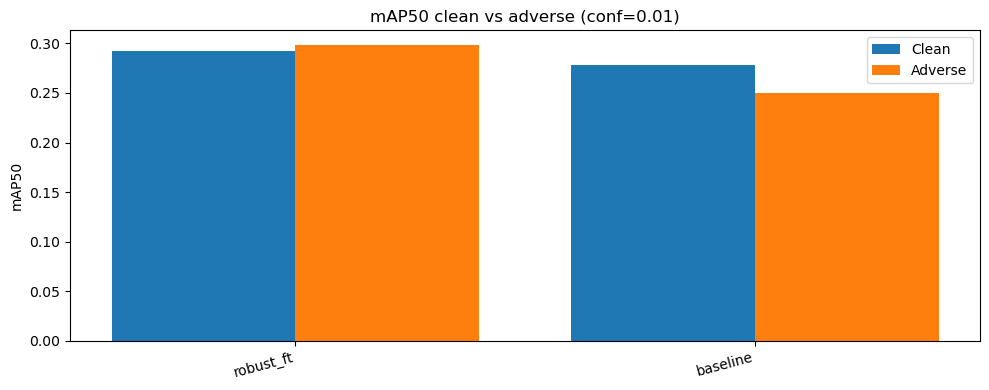

In [14]:
# Plot clean vs adverse mAP50
%matplotlib inline
plt.figure(figsize=(10, 4))
x = range(len(df))
plt.bar([i - 0.2 for i in x], df["clean mAP50"], width=0.4, label="Clean")
plt.bar([i + 0.2 for i in x], df["adverse mAP50"], width=0.4, label="Adverse")
plt.xticks(list(x), df["model"], rotation=15, ha="right")
plt.ylabel("mAP50")
plt.title(f"mAP50 clean vs adverse (conf={EVAL_CONF})")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# detections per image
test_imgs = list_images(ROAD4_CLEAN_DIR / "images" / "test")
m2 = YOLO(str(robust_best))
counts2 = []
for p in test_imgs:
    r = m2.predict(source=str(p), imgsz=640, conf=EVAL_CONF, verbose=False)[0]
    counts2.append(len(r.boxes))
print("Detections per test image (robust):", counts2, "avg:", (sum(counts2)/len(counts2) if counts2 else 0))

Detections per test image (robust): [43, 19, 10, 16, 8] avg: 19.2


In [16]:
# Low-confidence evaluation to check robustness stability
EVAL_CONF_LOW = 0.001

base_clean_low = eval_model(str(baseline_best), str(CLEAN_YAML), split="test", conf=EVAL_CONF_LOW, iou=EVAL_IOU)
base_adv_low   = eval_model(str(baseline_best), str(ADVERSE_YAML), split="test", conf=EVAL_CONF_LOW, iou=EVAL_IOU)
rob_clean_low  = eval_model(str(robust_best), str(CLEAN_YAML), split="test", conf=EVAL_CONF_LOW, iou=EVAL_IOU)
rob_adv_low    = eval_model(str(robust_best), str(ADVERSE_YAML), split="test", conf=EVAL_CONF_LOW, iou=EVAL_IOU)

print_metrics("BASELINE (conf=0.001) — Clean", base_clean_low)
print_metrics("BASELINE (conf=0.001) — Adverse", base_adv_low)
print_metrics("ROBUST   (conf=0.001) — Clean", rob_clean_low)
print_metrics("ROBUST   (conf=0.001) — Adverse", rob_adv_low)

df_low = pd.DataFrame([
    robustness_summary("baseline_lowconf", base_clean_low, base_adv_low),
    robustness_summary("robust_lowconf",   rob_clean_low,  rob_adv_low),
]).sort_values("robustness ratio mAP50", ascending=False)

print("Comparison (conf=0.001):")
display(df_low)

Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2354.5±662.4 MB/s, size: 42.5 KB)
val: Scanning /Users/rawanr/Downloads/AI_Assessment_Submission/data/road4_clean/labels/test.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 2.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9it/s 0.3s
                   all          5         13      0.749      0.231      0.275      0.171
Speed: 0.8ms preprocess, 64.4ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /Users/rawanr/Downloads/AI_Assessment_Submission/runs/detect/val15
Ultralytics 8.4.19 🚀 Python-3.9.13 torch-2.6.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3756.6±774.7 MB/s, size: 104

,model,clean mAP50,adverse mAP50,robustness ratio mAP50,drop mAP50,clean mAP50 95,adverse mAP50 95,robustness ratio mAP50 95,drop mAP50 95
1,robust_lowconf,0.286140,0.289193,1.010672,0.000000,0.091917,0.081638,0.888166,0.010279
0,baseline_lowconf,0.274959,0.252911,0.919815,0.022048,0.170700,0.138948,0.813989,0.031752
